# Simulation of the article *Nonlinear decision-making with enzymatic neural networks*, Nature 2022, from Okumura, Gines, Lobato-Dauzier, Baccouche, Deteix, Fujii, Rondelez, and Genot

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

plt.rcParams['font.family'] = 'Arial'


# Get the absolute path to the root directory
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)


from PEN_simulation import PEN_System
from strands import Signal, Drain, Template, Reporter


# Saving figs
saving=True
if saving:
    os.makedirs("figures/neural_network", exist_ok=True)

## 1) Linear Classifiers

In [2]:
def linear_classifier(temperature=45, 
                      BsmI_conc=400,
                      NBI_conc=0,
                      pol_conc=40,
                      exo_conc=3,
                      leak=0,
                      X1_conc=0, 
                      X2_conc=0, 
                      alpha_conc=0, 
                      f_conc=0, 
                      drain_alpha_conc=0, 
                      aT_alpha_conc=0, 
                      cT_X1_alpha_conc=0, 
                      cT_X2_alpha_conc=0, 
                      cT_X1_dTalpha_conc=0, 
                      cT_X1_dtf_conc=0, 
                      cT_X1_f_conc=0, 
                      cT_X2_f_conc=0, 
                      rT_conc=0):
    """Create a system with a signal and a drain"""
    system = PEN_System(temperature=temperature)
    system.leak = leak
    system.concentration_BsmI=BsmI_conc
    system.concentration_NBI=NBI_conc
    system.concentration_pol= pol_conc
    system.concentration_exo= exo_conc

    # Create a signal
    X1 = Signal(name="X1", sequence="AGGCAAGATGCTGGCATAGCTGT", concentration=X1_conc, protected=False, IsDrained=False)
    X2 = Signal(name="X2", sequence="TAGCTTATCAGACTGATGTTGA", concentration=X2_conc, protected=False, IsDrained=False)
    IsDrained_alpha=( drain_alpha_conc > 0 or cT_X1_dTalpha_conc > 0 or cT_X1_dtf_conc > 0)
    alpha = Signal(name="alpha", sequence="CATTCTGGACTG", concentration=alpha_conc, protected=False, IsDrained=IsDrained_alpha)
    f = Signal(name="f", sequence="CATTCGTACAGA", concentration=f_conc, protected=False, IsDrained=False)


    system.add_signal(X1)
    system.add_signal(X2)
    system.add_signal(alpha)
    system.add_signal(f)

    # Create a drain
    drain_alpha = Drain(name="drain_alpha", input=alpha, concentration=drain_alpha_conc, sequence="TTCAGTCCAGAATG", protected=True)
    drain_alpha_prod = Drain(name="drain_alpha_prod", input=alpha, concentration=0, sequence="TTCAGTCCAGAATG", protected=False)
    drain_f = Drain(name="drain_f", input=alpha, concentration=0, sequence="TTTTTCAGTCCAGAATG", protected=False) # Weird name but according to the article


    if drain_alpha_conc > 0:
        # print("Adding drain_alpha")
        system.add_drain(drain_alpha)
    if cT_X1_dTalpha_conc > 0:
        # print("Adding drain_alpha_prod")
        system.add_drain(drain_alpha_prod)
    if cT_X1_dtf_conc > 0:
        # print("Adding drain_f")
        system.add_drain(drain_f)
    
    # Create a template
    aT_alpha = Template(name="aT_alpha", sequence='CAGTCCAGAATGCAGTCCAGAA', input=alpha, output=alpha, concentration=aT_alpha_conc, nick="BsmI", protected=True, irreversible=False, phosphorylated=True)
    cT_X1_alpha = Template(name="cT_X1_alpha", sequence='CAGTCCAGAATGCAAACAGCTATGCCAGCA', input=X1, output=alpha, concentration=cT_X1_alpha_conc, nick="BsmI", protected=True, irreversible=False)
    cT_X2_alpha = Template(name="cT_X2_alpha", sequence='CAGTCCAGAATGCAATCAACATCAGTCTGAT', input=X2, output=alpha, concentration=cT_X2_alpha_conc, nick="BsmI", protected=True, irreversible=False)
    cT_X1_dTalpha = Template(name="cT_X1_dTalpha", sequence='CATTCTGGACTGTTCAATGACTCACAGCTATGCCAGCA', input=X1, output=drain_alpha_prod, concentration=cT_X1_dTalpha_conc, nick="NBI", protected=True, irreversible=True)
    cT_X1_dtf = Template(name="cT_X1_df", sequence='CATTCTGGACTGTTTTTCAATGACTCACAGCTATGCCAGCA', input=X1, output=drain_f, concentration=cT_X1_dtf_conc, nick="NBI", protected=True, irreversible=True)
    cT_X1_f = Template(name="cT_X1_f", sequence='TCTGTACGAATGCAAACAGCTATGCCAGCA', input=X1, output=f, concentration=cT_X1_f_conc, nick="BsmI", protected=True, irreversible=False)
    cT_X2_f = Template(name="cT_X2_f", sequence='TCTGTACGAATGCAATCAACATCAGTCTGAT', input=X2, output=f, concentration=cT_X2_f_conc, nick="BsmI", protected=True, irreversible=False)


    # Create a Reporter
    if rT_conc > 0:
        rT_output = Signal(name="rT_output", sequence="CATTCAGAAT", concentration=0, protected=False, IsDrained=False)
        system.add_signal(rT_output)
        rT_alpha = Reporter(name="rT_alpha", input=alpha, fluorophore="FAM", quencher="BHQ1", sequence="ATTCTGAATGCAGTCCAGAAT", concentration=rT_conc, reversible=True, output=rT_output)
        system.add_reporter(rT_alpha)

    if aT_alpha_conc > 0:
        system.add_template(aT_alpha)
    if cT_X1_alpha_conc >0:
        system.add_template(cT_X1_alpha)
    if cT_X2_alpha_conc > 0:
        system.add_template(cT_X2_alpha)
    if cT_X1_dTalpha_conc > 0:
        system.add_template(cT_X1_dTalpha)
    if cT_X1_dtf_conc > 0:
        system.add_template(cT_X1_dtf)
    if cT_X1_f_conc > 0:
        system.add_template(cT_X1_f)
    if cT_X2_f_conc > 0:
        system.add_template(cT_X2_f)
    return system

### Fig.2a Positive Bulk

In [3]:
t= np.linspace(0, 6*60, 501)  # 6 hours

X_concs=np.linspace(0,1,7)

dict_results_pos_bulk={}

for i, X2_conc in enumerate(X_concs[::-1]):
    
    for j, X1_conc in enumerate(X_concs):
        system = linear_classifier(
            temperature=45,
            pol_conc=30/2, # Adjustment for Vent (slower than Bst), hard to find the right value
            exo_conc=23,
            BsmI_conc=400,
            aT_alpha_conc=30, 
            leak=6e-7, # Seems good
            drain_alpha_conc=30,  
            rT_conc=25,
            cT_X1_alpha_conc=1,
            cT_X2_alpha_conc=1,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
        )


        y=system.solve_system(t)
        fluo=system.fluorescence_list(y, "rT_alpha")
        dict_results_pos_bulk[(X1_conc, X2_conc)]=fluo





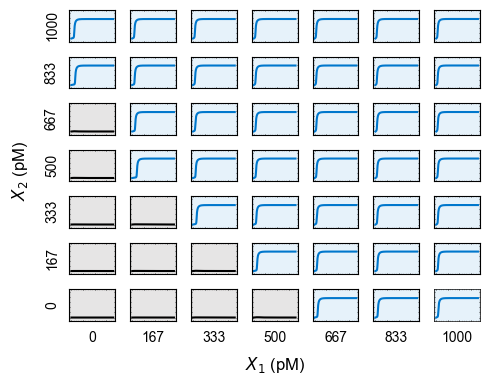

In [6]:
t= np.linspace(0, 6*60, 501)  # 6 hours
X_concs=np.linspace(0,1,7)

fig, axes = plt.subplots(len(X_concs), len(X_concs), figsize=(5, 4), sharey=True, sharex=True)

for i, X2_conc in enumerate(X_concs[::-1]):
    for j, X1_conc in enumerate(X_concs):
        fluo=dict_results_pos_bulk[(X1_conc, X2_conc)]

        if fluo[-1]<5:
            axes[i,j].plot(t, fluo, color='black')
            background_color = "#e6e5e5"
            axes[i,j].set_facecolor(background_color)
        else:
            axes[i,j].plot(t, fluo, color='#0077CC')
            background_color = "#E6F2FA"
            axes[i,j].set_facecolor(background_color)
        axes[i,j].set_ylim(-3,28)

        if i==len(X_concs)-1:
            axes[i,j].set_xlabel(round(X1_conc*1e3))
            axes[i,j].set_xticks([0,100,200,300])
            axes[i, j].set_xticklabels([])
            axes[i, j].xaxis.set_minor_locator(AutoMinorLocator(5))

        # Set ticks on all sides
        axes[i, j].xaxis.set_ticks_position('both')  # Ticks on both bottom and top
        axes[i, j].yaxis.set_ticks_position('both')  # Ticks on both left and right

        # Set tick directions to point inward
        axes[i, j].tick_params(
            axis='both',
            which='major',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=1,        # Tick length
            width=0.5          # Tick width
        )

        axes[i, j].tick_params(
            axis='both',
            which='minor',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=0.5,        # Tick length
            width=0.25         # Tick width
        )

        if j==0:
            axes[i,j].set_ylabel(round(X2_conc*1e3))
            axes[i,j].set_yticks([0,5,10,15,20,25])
            axes[i, j].set_yticklabels([])
            axes[i, j].yaxis.set_minor_locator(AutoMinorLocator(5))

fig.supxlabel(r'$X_1$ (pM)', fontsize=12, y=0.050, x=0.56)
fig.supylabel(r'$X_2$ (pM)', fontsize=12, y=0.56, x=0.03)

plt.tight_layout()
if saving:
    plt.savefig("figures/neural_network/pos_bulk1.pdf", dpi=300)



for spine in axes[i, j].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)  # Adjust this value to make the border thinner


plt.show()



Without tuning, we got the same behavior!

### Fig.2b Negative Bulk

In [7]:
t= np.linspace(0, 60*6, 1001) # 6 hours

X1_concs=np.linspace(0,1,7)
X2_concs=np.linspace(0.02,0.04,7) #Tuned

dict_results_neg_bulk={}

for i, X2_conc in enumerate(X2_concs[::-1]):
# for i, X2_conc in enumerate(X2_concs):
    
    for j, X1_conc in enumerate(X1_concs):
        system = linear_classifier(
            temperature=45,
            pol_conc=30/2, # Adjustment for Vent (slower than Bst), we don't know the right value
            exo_conc=23,
            BsmI_conc=400,
            NBI_conc=10,
            aT_alpha_conc=30,
            leak=6e-7, # Seems good
            drain_alpha_conc=5,
            rT_conc=25,
            cT_X1_dTalpha_conc=0.6,
            cT_X1_dtf_conc=0.4,
            cT_X2_alpha_conc=1,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
        )
        y=system.solve_system(t)
        fluo=system.fluorescence_list(y, "rT_alpha")
        dict_results_neg_bulk[(X1_conc, X2_conc)]=fluo





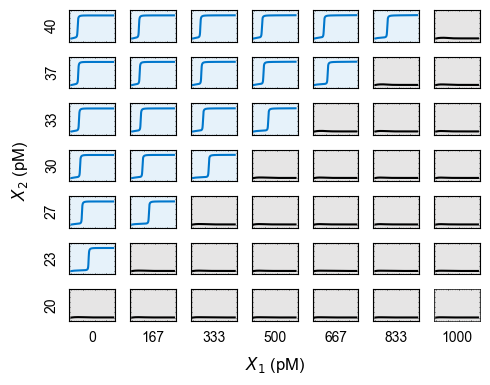

In [8]:
t= np.linspace(0, 6*60, 1001)  # 6 hours


fig, axes = plt.subplots(len(X2_concs), len(X1_concs), figsize=(5, 4), sharey=True, sharex=True)
for i, X2_conc in enumerate(X2_concs[::-1]):
    for j, X1_conc in enumerate(X1_concs):
        fluo=dict_results_neg_bulk[(X1_conc, X2_conc)] 
        if fluo[-1]<5:
            axes[i,j].plot(t, fluo, color='black')
            background_color = "#e6e5e5"
            axes[i,j].set_facecolor(background_color)
        else:
            axes[i,j].plot(t, fluo, color='#0077CC')
            background_color = "#E6F2FA"
            axes[i,j].set_facecolor(background_color)
        axes[i,j].set_ylim(-3,28)

        if i==len(X2_concs)-1:
            axes[i,j].set_xlabel(round(X1_conc*1e3))
            axes[i,j].set_xticks([0,100,200,300])
            axes[i, j].set_xticklabels([])
            axes[i, j].xaxis.set_minor_locator(AutoMinorLocator(5))

        # Set ticks on all sides
        axes[i, j].xaxis.set_ticks_position('both')  # Ticks on both bottom and top
        axes[i, j].yaxis.set_ticks_position('both')  # Ticks on both left and right

        # Set tick directions to point inward
        axes[i, j].tick_params(
            axis='both',
            which='major',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=1,        # Tick length
            width=0.5          # Tick width
        )

        axes[i, j].tick_params(
            axis='both',
            which='minor',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=0.5,        # Tick length
            width=0.25         # Tick width
        )

        if j==0:
            axes[i,j].set_ylabel(round(X2_conc*1e3))
            axes[i,j].set_yticks([0,5,10,15,20,25])
            axes[i, j].set_yticklabels([])
            axes[i, j].yaxis.set_minor_locator(AutoMinorLocator(5))

fig.supxlabel(r'$X_1$ (pM)', fontsize=12, y=0.050, x=0.56)
fig.supylabel(r'$X_2$ (pM)', fontsize=12, y=0.56, x=0.03)



for spine in axes[i, j].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)  # Adjust this value to make the border thinner


plt.tight_layout()

if saving:
    plt.savefig("figures/neural_network/neg_bulk1.pdf", dpi=300)
plt.show()


PEN System Summary
Temperature: 45 °C
Leak rate: 6e-07
Sodium concentration: 0.07 M
Magnesium concentration: 0.0125 M

--------------------------------------------------
Kinetic Rates Dictionary
--------------------------------------------------
X1              <-> cT_X1_dTalpha   : k_on = 4.94e-01 nM⁻¹·min⁻¹, k_off = 4.75e-01 min⁻¹
X1              <-> cT_X1_df        : k_on = 4.94e-01 nM⁻¹·min⁻¹, k_off = 4.75e-01 min⁻¹
X2              <-> cT_X2_alpha     : k_on = 3.22e-01 nM⁻¹·min⁻¹, k_off = 6.34e-01 min⁻¹
alpha           <-> aT_alpha        (input) : k_on = 7.31e-01 nM⁻¹·min⁻¹, k_off = 6.72e+02 min⁻¹
alpha           <-> aT_alpha        (output) : k_on = 4.82e-01 nM⁻¹·min⁻¹, k_off = 5.16e+01 min⁻¹
alpha           <-> cT_X2_alpha     : k_on = 4.82e-01 nM⁻¹·min⁻¹, k_off = 5.16e+01 min⁻¹
alpha           <-> drain_alpha     : k_on = 4.82e-01 nM⁻¹·min⁻¹, k_off = 5.16e+01 min⁻¹
alpha           <-> drain_alpha_prod : k_on = 4.82e-01 nM⁻¹·min⁻¹, k_off = 5.16e+01 min⁻¹
alpha           <-> drai

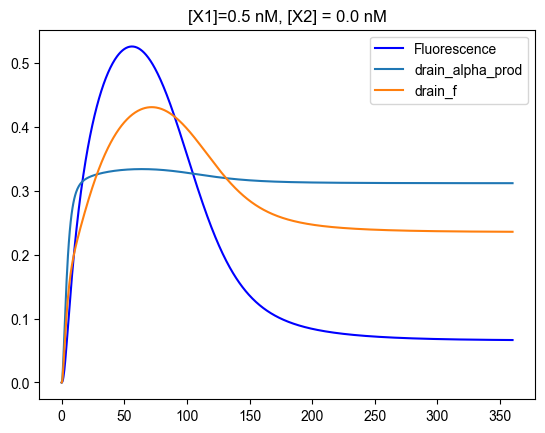

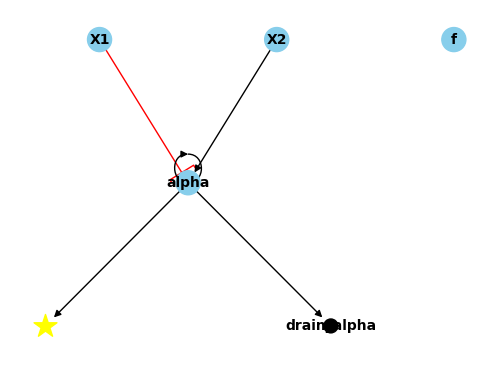

In [9]:
X1_conc=0.5
X2_conc=0.03

t= np.linspace(0, 6*60, 1001) #1000 minutes

system = linear_classifier(
            temperature=45,
            pol_conc=30/2, # Adjustment for Vent (slower than Bst), we don't know the right value
            exo_conc=23,
            BsmI_conc=400,
            NBI_conc=10,
            aT_alpha_conc=30,
            leak=6e-7, # Seems good
            drain_alpha_conc=5,
            rT_conc=25,
            cT_X1_dTalpha_conc=0.6,
            cT_X1_dtf_conc=0.4,
            cT_X2_alpha_conc=1,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
        )

y=system.solve_system(t)
fluo=system.fluorescence_list(y, "rT_alpha")
if fluo[-1]<5:
            plt.plot(t, fluo, color='blue', label='Fluorescence')
else:
            plt.plot(t, fluo, color='green', label='Fluorescence')

drain_prod_list=system.concentration_list(y,"drain_alpha_prod", "all")
plt.plot(t, drain_prod_list, label='drain_alpha_prod')
drainf_list=system.concentration_list(y,"drain_f", "all")
plt.plot(t, drainf_list, label='drain_f')



plt.title(f'[X1]={X1_conc:.1f} nM, [X2] = {X2_conc:.1f} nM')

plt.legend()

if i==0:
            plt.xlabel('Time (min)')
if i==0:
            plt.ylabel('Fluorescence (a.u.)')

plt.plot()
system.print(detailed_kinetics=True)
system.graph_representation(size=0.3)
system.unmalloc()

Again, we get the same behaviour, up to some parameters (drain concentration, polymerase activity)

## Adjust the linear classifier

### Fig.2c Positive droplet 1

In [10]:
t= np.linspace(0, 6*60, 501)  # 6 hours

X_concs=np.linspace(0,1,7)

dict_results_pos_drop1={}

for i, X2_conc in enumerate(X_concs[::-1]):
    
    for j, X1_conc in enumerate(X_concs):
        system = linear_classifier(
            temperature=45,
            pol_conc=30/2, # Adjustment for Vent (slower than Bst), hard to find the right value
            exo_conc=23,
            BsmI_conc=400,
            aT_alpha_conc=30, 
            leak=6e-7, # Seems good
            drain_alpha_conc=15, 
            rT_conc=25,
            cT_X1_alpha_conc=0.5,
            cT_X1_f_conc=0.5,
            cT_X2_alpha_conc=0.5,
            cT_X2_f_conc=0.5,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
        )

        y=system.solve_system(t)
        fluo=system.fluorescence_list(y, "rT_alpha")
        dict_results_pos_drop1[(X1_conc, X2_conc)]=fluo





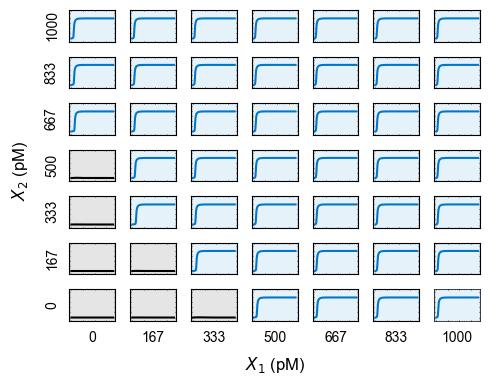

In [11]:
t= np.linspace(0, 6*60, 501)  # 6 hours
X_concs=np.linspace(0,1,7)

fig, axes = plt.subplots(len(X_concs), len(X_concs), figsize=(5, 4), sharey=True, sharex=True)

for i, X2_conc in enumerate(X_concs[::-1]):
    for j, X1_conc in enumerate(X_concs):
        fluo=dict_results_pos_drop1[(X1_conc, X2_conc)]

        if fluo[-1]<5:
            axes[i,j].plot(t, fluo, color='black')
            background_color = "#e6e5e5"
            axes[i,j].set_facecolor(background_color)
        else:
            axes[i,j].plot(t, fluo, color='#0077CC')
            background_color = "#E6F2FA"
            axes[i,j].set_facecolor(background_color)
        axes[i,j].set_ylim(-3,28)

        if i==len(X_concs)-1:
            axes[i,j].set_xlabel(round(X1_conc*1e3))
            axes[i,j].set_xticks([0,100,200,300])
            axes[i, j].set_xticklabels([])
            axes[i, j].xaxis.set_minor_locator(AutoMinorLocator(5))

        # Set ticks on all sides
        axes[i, j].xaxis.set_ticks_position('both')  # Ticks on both bottom and top
        axes[i, j].yaxis.set_ticks_position('both')  # Ticks on both left and right

        # Set tick directions to point inward
        axes[i, j].tick_params(
            axis='both',
            which='major',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=1,        # Tick length
            width=0.5          # Tick width
        )

        axes[i, j].tick_params(
            axis='both',
            which='minor',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=0.5,        # Tick length
            width=0.25         # Tick width
        )

        if j==0:
            axes[i,j].set_ylabel(round(X2_conc*1e3))
            axes[i,j].set_yticks([0,5,10,15,20,25])
            axes[i, j].set_yticklabels([])
            axes[i, j].yaxis.set_minor_locator(AutoMinorLocator(5))

fig.supxlabel(r'$X_1$ (pM)', fontsize=12, y=0.050, x=0.56)
fig.supylabel(r'$X_2$ (pM)', fontsize=12, y=0.56, x=0.03)


plt.tight_layout()
if saving:
    plt.savefig("figures/neural_network/pos_drop1.pdf", dpi=300)



for spine in axes[i, j].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)  # Adjust this value to make the border thinner


plt.show()



### Fig.2c Positive droplet 2

In [12]:
t= np.linspace(0, 6*60, 501)  # 6 hours

X_concs=np.linspace(0,1,7)

dict_results_pos_drop2={}

for i, X2_conc in enumerate(X_concs[::-1]):
    
    for j, X1_conc in enumerate(X_concs):
        system = linear_classifier(
            temperature=45,
            pol_conc=30/2, # Adjustment for Vent (slower than Bst), hard to find the right value
            exo_conc=23,
            BsmI_conc=400,
            aT_alpha_conc=30, 
            leak=6e-7, # Seems good
            drain_alpha_conc=15, 
            rT_conc=25,
            cT_X1_alpha_conc=0.75,
            cT_X1_f_conc=0.25,
            cT_X2_alpha_conc=0.25, # I suppose there is a mistake in the SI here, as it is not coherent the the schematic of fig. 2
            cT_X2_f_conc=0.75,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
        )

        y=system.solve_system(t)
        fluo=system.fluorescence_list(y, "rT_alpha")
        dict_results_pos_drop2[(X1_conc, X2_conc)]=fluo





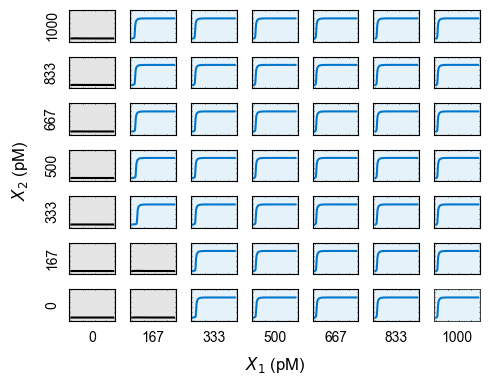

In [13]:
t= np.linspace(0, 6*60, 501)  # 6 hours
X_concs=np.linspace(0,1,7)

fig, axes = plt.subplots(len(X_concs), len(X_concs), figsize=(5, 4), sharey=True, sharex=True)

for i, X2_conc in enumerate(X_concs[::-1]):
    for j, X1_conc in enumerate(X_concs):
        fluo=dict_results_pos_drop2[(X1_conc, X2_conc)]

        if fluo[-1]<5:
            axes[i,j].plot(t, fluo, color='black')
            background_color = "#e6e5e5"
            axes[i,j].set_facecolor(background_color)
        else:
            axes[i,j].plot(t, fluo, color='#0077CC')
            background_color = "#E6F2FA"
            axes[i,j].set_facecolor(background_color)
        axes[i,j].set_ylim(-3,28)

        if i==len(X_concs)-1:
            axes[i,j].set_xlabel(round(X1_conc*1e3))
            axes[i,j].set_xticks([0,100,200,300])
            axes[i, j].set_xticklabels([])
            axes[i, j].xaxis.set_minor_locator(AutoMinorLocator(5))

        # Set ticks on all sides
        axes[i, j].xaxis.set_ticks_position('both')  # Ticks on both bottom and top
        axes[i, j].yaxis.set_ticks_position('both')  # Ticks on both left and right

        # Set tick directions to point inward
        axes[i, j].tick_params(
            axis='both',
            which='major',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=1,        # Tick length
            width=0.5          # Tick width
        )

        axes[i, j].tick_params(
            axis='both',
            which='minor',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=0.5,        # Tick length
            width=0.25         # Tick width
        )

        if j==0:
            axes[i,j].set_ylabel(round(X2_conc*1e3))
            axes[i,j].set_yticks([0,5,10,15,20,25])
            axes[i, j].set_yticklabels([])
            axes[i, j].yaxis.set_minor_locator(AutoMinorLocator(5))

fig.supxlabel(r'$X_1$ (pM)', fontsize=12, y=0.050, x=0.56)
fig.supylabel(r'$X_2$ (pM)', fontsize=12, y=0.56, x=0.03)

plt.tight_layout()
if saving:
    plt.savefig("figures/neural_network/pos_drop2.pdf", dpi=300)



for spine in axes[i, j].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)  # Adjust this value to make the border thinner


plt.show()



### Fig.2c Positive droplet 3

In [14]:
t= np.linspace(0, 6*60, 501)  # 6 hours

X_concs=np.linspace(0,1,7)

dict_results_pos_drop3={}

for i, X2_conc in enumerate(X_concs[::-1]):
    
    for j, X1_conc in enumerate(X_concs):
        system = linear_classifier(
            temperature=45,
            pol_conc=30/2, # Adjustment for Vent (slower than Bst), hard to find the right value
            exo_conc=23,
            BsmI_conc=400,
            aT_alpha_conc=30, 
            leak=6e-7, # Seems good
            drain_alpha_conc=18, 
            rT_conc=25,
            cT_X1_alpha_conc=0.5,
            cT_X1_f_conc=0.5,
            cT_X2_alpha_conc=0.5,
            cT_X2_f_conc=0.5,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
        )

        y=system.solve_system(t)
        fluo=system.fluorescence_list(y, "rT_alpha")
        dict_results_pos_drop3[(X1_conc, X2_conc)]=fluo





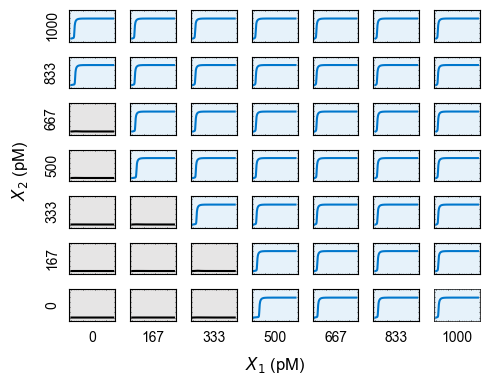

In [15]:
t= np.linspace(0, 6*60, 501)  # 6 hours
X_concs=np.linspace(0,1,7)

fig, axes = plt.subplots(len(X_concs), len(X_concs), figsize=(5, 4), sharey=True, sharex=True)

for i, X2_conc in enumerate(X_concs[::-1]):
    for j, X1_conc in enumerate(X_concs):
        fluo=dict_results_pos_drop3[(X1_conc, X2_conc)]

        if fluo[-1]<5:
            axes[i,j].plot(t, fluo, color='black')
            background_color = "#e6e5e5"
            axes[i,j].set_facecolor(background_color)
        else:
            axes[i,j].plot(t, fluo, color='#0077CC')
            background_color = "#E6F2FA"
            axes[i,j].set_facecolor(background_color)
        axes[i,j].set_ylim(-3,28)

        if i==len(X_concs)-1:
            axes[i,j].set_xlabel(round(X1_conc*1e3))
            axes[i,j].set_xticks([0,100,200,300])
            axes[i, j].set_xticklabels([])
            axes[i, j].xaxis.set_minor_locator(AutoMinorLocator(5))

        # Set ticks on all sides
        axes[i, j].xaxis.set_ticks_position('both')  # Ticks on both bottom and top
        axes[i, j].yaxis.set_ticks_position('both')  # Ticks on both left and right

        # Set tick directions to point inward
        axes[i, j].tick_params(
            axis='both',
            which='major',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=1,        # Tick length
            width=0.5          # Tick width
        )

        axes[i, j].tick_params(
            axis='both',
            which='minor',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=0.5,        # Tick length
            width=0.25         # Tick width
        )

        if j==0:
            axes[i,j].set_ylabel(round(X2_conc*1e3))
            axes[i,j].set_yticks([0,5,10,15,20,25])
            axes[i, j].set_yticklabels([])
            axes[i, j].yaxis.set_minor_locator(AutoMinorLocator(5))

fig.supxlabel(r'$X_1$ (pM)', fontsize=12, y=0.050, x=0.56)
fig.supylabel(r'$X_2$ (pM)', fontsize=12, y=0.56, x=0.03)


plt.tight_layout()
if saving:
    plt.savefig("figures/neural_network/pos_drop3.pdf", dpi=300)



for spine in axes[i, j].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)  # Adjust this value to make the border thinner


plt.show()



### Fig. 2d Negative droplet 1 (46°C instead of 41.8°C)

In [16]:
t= np.linspace(0, 60*6, 1001) # 6 hours

X1_concs=np.linspace(0,1,7)
X2_concs=np.linspace(0,1,7) #Tuned

dict_results_neg_drop1={}

for i, X2_conc in enumerate(X2_concs[::-1]):
# for i, X2_conc in enumerate(X2_concs):
    
    for j, X1_conc in enumerate(X1_concs):
        system = linear_classifier(
            temperature=46,
            pol_conc=30/2, # Adjustment for Vent (slower than Bst), we don't know the right value
            exo_conc=23,
            BsmI_conc=400,
            NBI_conc=10,
            aT_alpha_conc=30,
            leak=6e-7, # Seems good
            drain_alpha_conc=5,
            rT_conc=25,
            cT_X1_dTalpha_conc=0.6,
            cT_X1_dtf_conc=0.4,
            cT_X2_alpha_conc=1,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
        )
        y=system.solve_system(t)
        fluo=system.fluorescence_list(y, "rT_alpha")
        dict_results_neg_drop1[(X1_conc, X2_conc)]=fluo


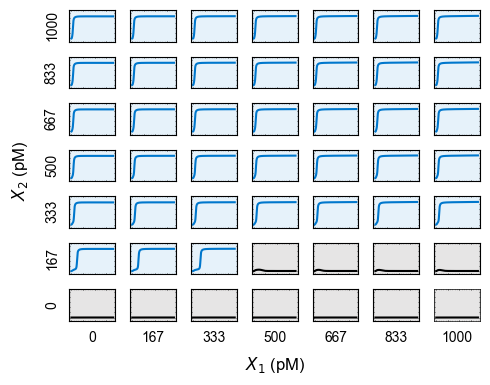

In [17]:
t= np.linspace(0, 6*60, 1001)  # 6 hours


fig, axes = plt.subplots(len(X2_concs), len(X1_concs), figsize=(5, 4), sharey=True, sharex=True)
for i, X2_conc in enumerate(X2_concs[::-1]):
    for j, X1_conc in enumerate(X1_concs):
        fluo=dict_results_neg_drop1[(X1_conc, X2_conc)] 
        if fluo[-1]<5:
            axes[i,j].plot(t, fluo, color='black')
            background_color = "#e6e5e5"
            axes[i,j].set_facecolor(background_color)
        else:
            axes[i,j].plot(t, fluo, color='#0077CC')
            background_color = "#E6F2FA"
            axes[i,j].set_facecolor(background_color)
        axes[i,j].set_ylim(-3,28)

        if i==len(X2_concs)-1:
            axes[i,j].set_xlabel(round(X1_conc*1e3))
            axes[i,j].set_xticks([0,100,200,300])
            axes[i, j].set_xticklabels([])
            axes[i, j].xaxis.set_minor_locator(AutoMinorLocator(5))

        # Set ticks on all sides
        axes[i, j].xaxis.set_ticks_position('both')  # Ticks on both bottom and top
        axes[i, j].yaxis.set_ticks_position('both')  # Ticks on both left and right

        # Set tick directions to point inward
        axes[i, j].tick_params(
            axis='both',
            which='major',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=1,        # Tick length
            width=0.5          # Tick width
        )

        axes[i, j].tick_params(
            axis='both',
            which='minor',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=0.5,        # Tick length
            width=0.25         # Tick width
        )

        if j==0:
            axes[i,j].set_ylabel(round(X2_conc*1e3))
            axes[i,j].set_yticks([0,5,10,15,20,25])
            axes[i, j].set_yticklabels([])
            axes[i, j].yaxis.set_minor_locator(AutoMinorLocator(5))

fig.supxlabel(r'$X_1$ (pM)', fontsize=12, y=0.050, x=0.56)
fig.supylabel(r'$X_2$ (pM)', fontsize=12, y=0.56, x=0.03)



for spine in axes[i, j].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)  # Adjust this value to make the border thinner


plt.tight_layout()

if saving:
    plt.savefig("figures/neural_network/neg_drop1.pdf", dpi=300)
plt.show()


### Fig. 2d Negative droplet 2 (46.5°C instead of 42.6°C)

In [18]:
t= np.linspace(0, 60*6, 1001) # 6 hours

X1_concs=np.linspace(0,1,7)
X2_concs=np.linspace(0,1,7) #Tuned

dict_results_neg_drop2={}

for i, X2_conc in enumerate(X2_concs[::-1]):
# for i, X2_conc in enumerate(X2_concs):
    
    for j, X1_conc in enumerate(X1_concs):
        system = linear_classifier(
            temperature=46.5,
            pol_conc=30/2, # Adjustment for Vent (slower than Bst), we don't know the right value
            exo_conc=23,
            BsmI_conc=400,
            NBI_conc=10,
            aT_alpha_conc=30,
            leak=6e-7, # Seems good
            drain_alpha_conc=5,
            rT_conc=25,
            cT_X1_dTalpha_conc=0.6,
            cT_X1_dtf_conc=0.4,
            cT_X2_alpha_conc=1,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
        )
        y=system.solve_system(t)
        fluo=system.fluorescence_list(y, "rT_alpha")
        dict_results_neg_drop2[(X1_conc, X2_conc)]=fluo


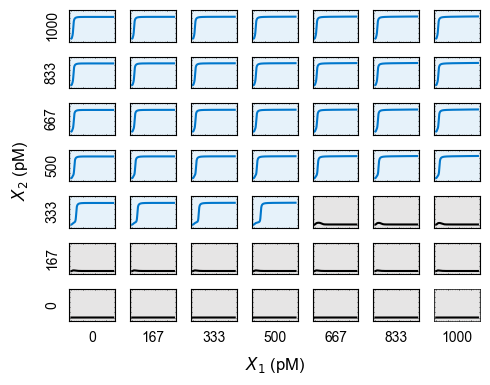

In [19]:
t= np.linspace(0, 6*60, 1001)  # 6 hours


fig, axes = plt.subplots(len(X2_concs), len(X1_concs), figsize=(5, 4), sharey=True, sharex=True)
for i, X2_conc in enumerate(X2_concs[::-1]):
    for j, X1_conc in enumerate(X1_concs):
        fluo=dict_results_neg_drop2[(X1_conc, X2_conc)] 
        if fluo[-1]<5:
            axes[i,j].plot(t, fluo, color='black')
            background_color = "#e6e5e5"
            axes[i,j].set_facecolor(background_color)
        else:
            axes[i,j].plot(t, fluo, color='#0077CC')
            background_color = "#E6F2FA"
            axes[i,j].set_facecolor(background_color)
        axes[i,j].set_ylim(-3,28)

        if i==len(X2_concs)-1:
            axes[i,j].set_xlabel(round(X1_conc*1e3))
            axes[i,j].set_xticks([0,100,200,300])
            axes[i, j].set_xticklabels([])
            axes[i, j].xaxis.set_minor_locator(AutoMinorLocator(5))

        # Set ticks on all sides
        axes[i, j].xaxis.set_ticks_position('both')  # Ticks on both bottom and top
        axes[i, j].yaxis.set_ticks_position('both')  # Ticks on both left and right

        # Set tick directions to point inward
        axes[i, j].tick_params(
            axis='both',
            which='major',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=1,        # Tick length
            width=0.5          # Tick width
        )

        axes[i, j].tick_params(
            axis='both',
            which='minor',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=0.5,        # Tick length
            width=0.25         # Tick width
        )

        if j==0:
            axes[i,j].set_ylabel(round(X2_conc*1e3))
            axes[i,j].set_yticks([0,5,10,15,20,25])
            axes[i, j].set_yticklabels([])
            axes[i, j].yaxis.set_minor_locator(AutoMinorLocator(5))

fig.supxlabel(r'$X_1$ (pM)', fontsize=12, y=0.050, x=0.56)
fig.supylabel(r'$X_2$ (pM)', fontsize=12, y=0.56, x=0.03)



for spine in axes[i, j].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)  # Adjust this value to make the border thinner


plt.tight_layout()

if saving:
    plt.savefig("figures/neural_network/neg_drop2.pdf", dpi=300)
plt.show()


### Fig. 2d Negative droplet 2 (47°C instead of 43.3°C)

In [20]:
t= np.linspace(0, 60*6, 1001) # 6 hours

X1_concs=np.linspace(0,1,7)
X2_concs=np.linspace(0,1,7) #Tuned

dict_results_neg_drop3={}

for i, X2_conc in enumerate(X2_concs[::-1]):
# for i, X2_conc in enumerate(X2_concs):
    
    for j, X1_conc in enumerate(X1_concs):
        system = linear_classifier(
            temperature=47,
            pol_conc=30/2, # Adjustment for Vent (slower than Bst), we don't know the right value
            exo_conc=23,
            BsmI_conc=400,
            NBI_conc=10,
            aT_alpha_conc=30,
            leak=6e-7, # Seems good
            drain_alpha_conc=5,
            rT_conc=25,
            cT_X1_dTalpha_conc=0.6,
            cT_X1_dtf_conc=0.4,
            cT_X2_alpha_conc=1,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
        )
        y=system.solve_system(t)
        fluo=system.fluorescence_list(y, "rT_alpha")
        dict_results_neg_drop3[(X1_conc, X2_conc)]=fluo


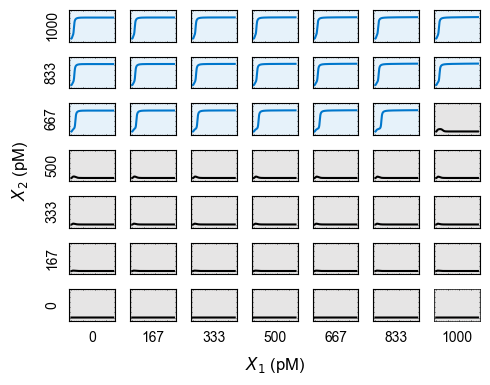

In [21]:
t= np.linspace(0, 6*60, 1001)  # 6 hours


fig, axes = plt.subplots(len(X2_concs), len(X1_concs), figsize=(5, 4), sharey=True, sharex=True)
for i, X2_conc in enumerate(X2_concs[::-1]):
    for j, X1_conc in enumerate(X1_concs):
        fluo=dict_results_neg_drop3[(X1_conc, X2_conc)] 
        if fluo[-1]<5:
            axes[i,j].plot(t, fluo, color='black')
            background_color = "#e6e5e5"
            axes[i,j].set_facecolor(background_color)
        else:
            axes[i,j].plot(t, fluo, color='#0077CC')
            background_color = "#E6F2FA"
            axes[i,j].set_facecolor(background_color)
        axes[i,j].set_ylim(-3,28)

        if i==len(X2_concs)-1:
            axes[i,j].set_xlabel(round(X1_conc*1e3))
            axes[i,j].set_xticks([0,100,200,300])
            axes[i, j].set_xticklabels([])
            axes[i, j].xaxis.set_minor_locator(AutoMinorLocator(5))

        # Set ticks on all sides
        axes[i, j].xaxis.set_ticks_position('both')  # Ticks on both bottom and top
        axes[i, j].yaxis.set_ticks_position('both')  # Ticks on both left and right

        # Set tick directions to point inward
        axes[i, j].tick_params(
            axis='both',
            which='major',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=1,        # Tick length
            width=0.5          # Tick width
        )

        axes[i, j].tick_params(
            axis='both',
            which='minor',
            direction='in',  # Ticks point inward
            top=True,        # Ticks on top
            right=True,      # Ticks on right
            length=0.5,        # Tick length
            width=0.25         # Tick width
        )

        if j==0:
            axes[i,j].set_ylabel(round(X2_conc*1e3))
            axes[i,j].set_yticks([0,5,10,15,20,25])
            axes[i, j].set_yticklabels([])
            axes[i, j].yaxis.set_minor_locator(AutoMinorLocator(5))

fig.supxlabel(r'$X_1$ (pM)', fontsize=12, y=0.050, x=0.56)
fig.supylabel(r'$X_2$ (pM)', fontsize=12, y=0.56, x=0.03)



for spine in axes[i, j].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)  # Adjust this value to make the border thinner


plt.tight_layout()

if saving:
    plt.savefig("figures/neural_network/neg_drop3.pdf", dpi=300)
plt.show()


# Conclusion

PENSim successfully qualifies the behaviors of linear classifiers and their dependencies on template concentrations, with the same parameters than used experimentally!
 However, the quantitative agreement for negative-weighted classifiers remains limited, suggesting the need for further investigation in future work.

Another notable limitation is computational efficiency. For systems comprising many templates and signals—especially when ranging multiple parameters—simulations require approximately 2 minutes per run, which may be considered slow for certain applications. This aspect could benefit from optimization in future developments.
